# Pilot SV Δp — hot vs cold (sites 4 / 54)

The 2-site preview of the paper's climate-gradient signature, but with **SVs**:
for each structural variant, frequency change from the founding seed mix (p0) in
the **hot** garden vs the **cold** garden. SVs that go **up in hot & down in cold**
(or vice versa) are candidate climate-adaptive SVs — the anti-diagonal of the
cross-site Δp scatter (cf. the paper's Konstanz-vs-Madrid panel).

Run in the `plotting` env. Inferential climate-GEA (LFMM/WZA/selection model)
needs the full ~30-site cohort; here we identify candidates and sanity-check the
signal. See ../README.md.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import lib
plt.rcParams['figure.dpi'] = 110

## 1. Load group means, compute per-SV Δp from p0

In [2]:
gm = lib.build_group_means()            # cached parquet; record meta + p0 + <clim>_g<gen>
sv = lib.is_sv(gm).values
print('records:', len(gm), '| SVs:', sv.sum())

# cumulative Δp by last generation (gen 3) in each climate, SVs only
d = gm[sv].copy()
d['dp_hot']  = d['hot_g3']  - d['p0']
d['dp_cold'] = d['cold_g3'] - d['p0']
d['sv_size'] = (d.alt_len - d.ref_len).abs()
d = d[d.dp_hot.notna() & d.dp_cold.notna() & d.p0.notna()]
print('SVs with Δp in both climates:', len(d))
d[['chrom','pos','ref_len','alt_len','p0','dp_hot','dp_cold','sv_size']].head()

records: 10325364 | SVs: 314303
SVs with Δp in both climates: 314303


,chrom,pos,ref_len,alt_len,p0,dp_hot,dp_cold,sv_size
0,Chr1,2,67,2465,0.000000,0.000000,0.000000,2398
1,Chr1,2,1,2161,0.050886,-0.046514,-0.004304,2160
2,Chr1,2,1,4527,0.020640,-0.018540,0.018761,4526
3,Chr1,2,1,2334,0.003261,0.008181,-0.002814,2333
4,Chr1,2,1,2706,0.008094,-0.006777,-0.007320,2705


## 2. The cross-climate Δp scatter (the target figure, 2-site form)
Density of all SVs; anti-diagonal (up-in-hot / down-in-cold) = climate-divergent candidates.

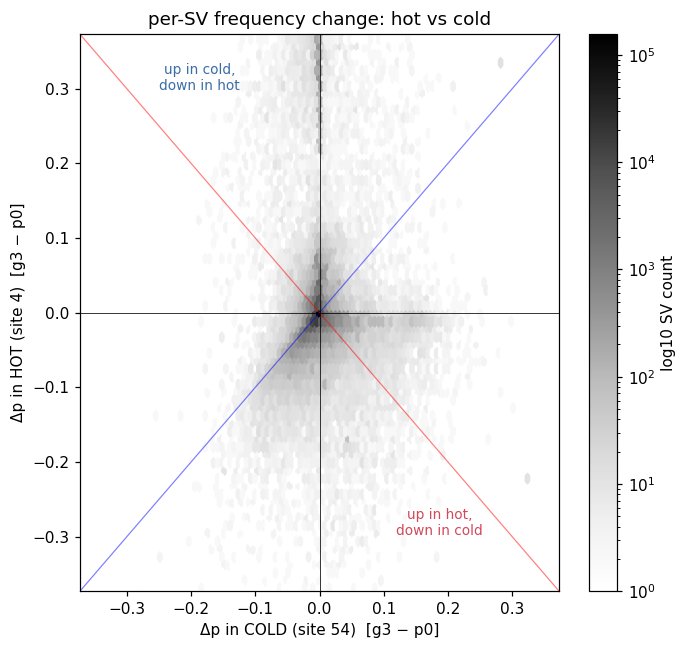

cross-climate Δp correlation (Pearson r): 0.02


In [3]:
fig, ax = plt.subplots(figsize=(6.4,6))
hb = ax.hexbin(d.dp_cold, d.dp_hot, gridsize=120, bins='log', cmap='Greys', mincnt=1)
lim = np.nanpercentile(np.abs(np.r_[d.dp_hot, d.dp_cold]), 99.5)
ax.plot([-lim,lim],[-lim,lim],'b-',lw=.8,alpha=.5)          # y=x (parallel response)
ax.plot([-lim,lim],[lim,-lim],'r-',lw=.8,alpha=.5)          # anti-diagonal (divergent)
ax.axhline(0,c='k',lw=.5); ax.axvline(0,c='k',lw=.5)
ax.set(xlim=(-lim,lim), ylim=(-lim,lim),
       xlabel='Δp in COLD (site 54)  [g3 − p0]', ylabel='Δp in HOT (site 4)  [g3 − p0]',
       title='per-SV frequency change: hot vs cold')
ax.text(lim*.5, -lim*.8, 'up in hot,\ndown in cold', color='#d1495b', ha='center', fontsize=9)
ax.text(-lim*.5, lim*.8, 'up in cold,\ndown in hot', color='#3b6ea5', ha='center', fontsize=9)
fig.colorbar(hb, label='log10 SV count')
plt.tight_layout(); plt.savefig(f'{lib.GEA}/02_sv_dp_hot_vs_cold.png', dpi=130, bbox_inches='tight'); plt.show()
print('cross-climate Δp correlation (Pearson r):', round(np.corrcoef(d.dp_hot, d.dp_cold)[0,1], 3))

## 3. Candidate climate-adaptive SVs
Largest hot−cold divergence, requiring opposite-sign change (the anti-diagonal).

In [4]:
d['divergence'] = d.dp_hot - d.dp_cold              # >0: rises in hot relative to cold
d['opposite'] = np.sign(d.dp_hot) != np.sign(d.dp_cold)
# candidates: opposite sign AND large divergence AND not ultra-rare at founding
cand = d[(d.opposite) & (d.p0.between(0.02, 0.98))].copy()
cand = cand.reindex(cand.divergence.abs().sort_values(ascending=False).index)
print('candidate SVs (opposite-sign, 2-98% founding freq):', len(cand))
top = cand.head(20)[['chrom','pos','ref_len','alt_len','sv_size','p0','dp_hot','dp_cold','divergence']]
top.to_csv(f'{lib.GEA}/02_candidate_adaptive_svs.csv', index=False)
display(top.round(3))

candidate SVs (opposite-sign, 2-98% founding freq): 23313


,chrom,pos,ref_len,alt_len,sv_size,p0,dp_hot,dp_cold,divergence
2959510,Chr2,2680467,1,240,239,0.037,0.749,-0.025,0.774
5286899,Chr3,11718952,874,1242,368,0.028,0.744,-0.005,0.750
5284994,Chr3,11691620,1,2067,2066,0.028,0.744,-0.005,0.750
5285567,Chr3,11697087,20254,31147,10893,0.028,0.744,-0.005,0.750
5284415,Chr3,11681475,684,1,683,0.028,0.744,-0.005,0.750
1319095,Chr1,16666494,149,1,148,0.050,0.722,-0.027,0.749
7480336,Chr4,10576896,1,182,181,0.164,0.671,-0.067,0.738
6452039,Chr4,1204407,1,385,384,0.115,0.686,-0.035,0.721
5211457,Chr3,11172278,1,355,354,0.021,0.715,-0.007,0.721
1843925,Chr1,21758995,52,1,51,0.048,0.707,-0.011,0.719


## 4. Generation trajectories of top candidates
Mean SV frequency at p0 (gen0) → g1 → g2 → g3, hot (red) vs cold (blue) — the per-allele 'rises in hot / falls in cold' picture.

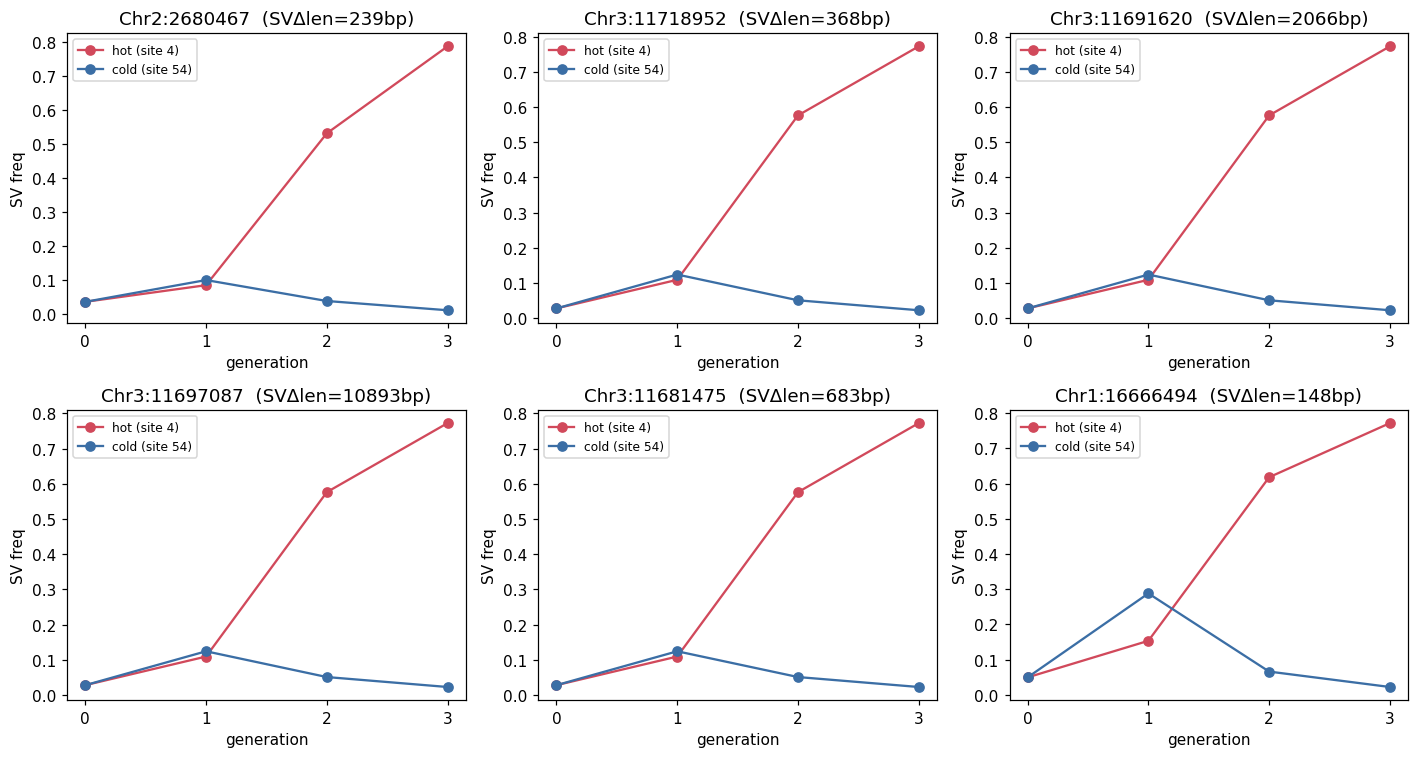

In [5]:
gens = [0,1,2,3]
def traj(row, clim):
    return [row['p0']] + [row.get(f'{clim}_g{g}', np.nan) for g in [1,2,3]]
# need the full gm row (has per-gen cols) for each candidate — join back by index
topidx = cand.head(6).index
fig, axes = plt.subplots(2,3, figsize=(13,7), sharey=False)
for ax,(i,row) in zip(axes.flat, gm.loc[topidx].iterrows()):
    ax.plot(gens, [row.p0]+[row.hot_g1,row.hot_g2,row.hot_g3], '-o', color='#d1495b', label='hot (site 4)')
    ax.plot(gens, [row.p0]+[row.cold_g1,row.cold_g2,row.cold_g3], '-o', color='#3b6ea5', label='cold (site 54)')
    sz = abs(int(row.alt_len-row.ref_len))
    ax.set(title=f'{row.chrom}:{int(row.pos)}  (SVΔlen={sz}bp)', xlabel='generation', ylabel='SV freq')
    ax.set_xticks(gens); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{lib.GEA}/02_candidate_trajectories.png', dpi=130, bbox_inches='tight'); plt.show()

## 5. Are large SVs enriched among candidates? + SV-vs-SNP comparison

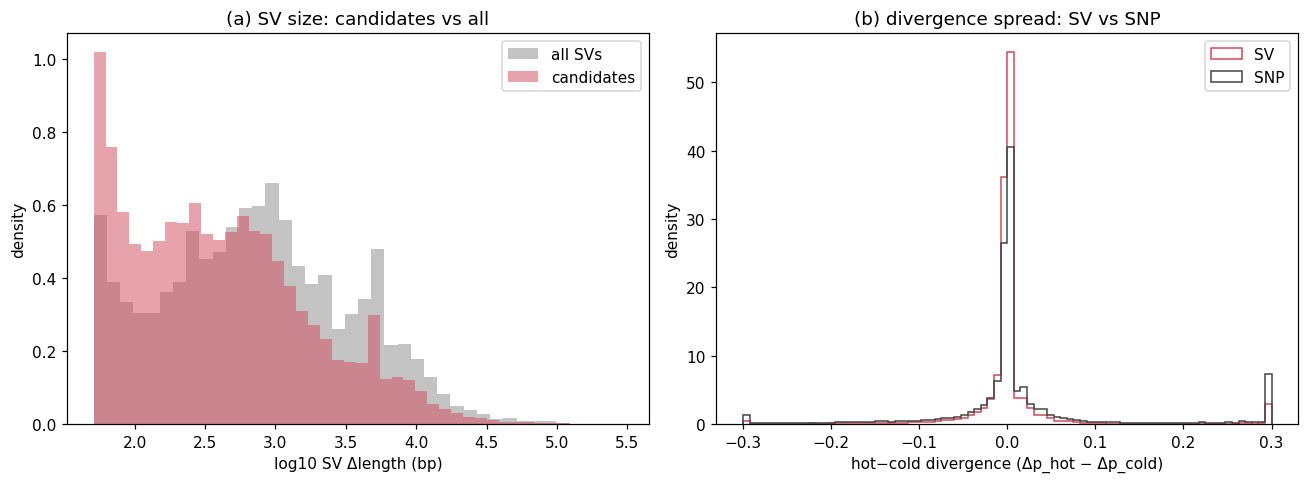

candidate SV size median: 342 bp  | all SV median: 706 bp


In [6]:
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
# (a) SV size: candidates vs all SVs
ax[0].hist(np.log10(d.sv_size.clip(lower=1)), bins=40, density=True, alpha=.5, label='all SVs', color='#888')
ax[0].hist(np.log10(cand.sv_size.clip(lower=1)), bins=40, density=True, alpha=.5, label='candidates', color='#d1495b')
ax[0].set(xlabel='log10 SV Δlength (bp)', ylabel='density', title='(a) SV size: candidates vs all'); ax[0].legend()

# (b) SV vs SNP: cross-climate divergence spread (do SVs show comparable/own signal?)
snp = lib.is_snp(gm).values
sn = gm[snp].copy(); sn['dp_hot']=sn.hot_g3-sn.p0; sn['dp_cold']=sn.cold_g3-sn.p0
sn = sn[sn.dp_hot.notna()&sn.dp_cold.notna()]
for lab,arr,col in [('SV', d.dp_hot-d.dp_cold, '#d1495b'), ('SNP', sn.dp_hot-sn.dp_cold, '#444')]:
    ax[1].hist(arr.clip(-.3,.3), bins=80, density=True, histtype='step', label=lab, color=col)
ax[1].set(xlabel='hot−cold divergence (Δp_hot − Δp_cold)', ylabel='density', title='(b) divergence spread: SV vs SNP'); ax[1].legend()
plt.tight_layout(); plt.savefig(f'{lib.GEA}/02_sv_size_and_snp_compare.png', dpi=130, bbox_inches='tight'); plt.show()
print('candidate SV size median: %.0f bp  | all SV median: %.0f bp' % (cand.sv_size.median(), d.sv_size.median()))

## Notes / caveats (pilot)
- 2 sites → **exploratory candidate ID only**, not significance (no climate
  replication). Real inference = full-cohort LFMM/WZA/selection model.
- Group means average over plots → reduce per-sample noise, but low-coverage
  samples (some 2.8×) still add error; a ≥3× floor + per-record SE weighting is a
  refinement.
- Δp uses cumulative g3−p0; a per-generation slope (gradient) is the cleaner
  statistic once more generations/sites are in (matches the paper's 'AF gradient').